# Deep Q-Network (DQN) — Hands-On Session

In this notebook we will build a complete DQN agent **from scratch**, train it on classic RL benchmarks, and visualize results.

### What you will implement:
1. **Replay Buffer** — experience storage & random sampling
2. **Q-Network** — the MLP that approximates Q-values
3. **DQN Agent** — ε-greedy policy + Bellman update + target network
4. **Training Loop** — environment interaction, logging, evaluation

### Environments we will use:
| Env | Action Space | Why |
|---|---|---|
| `CartPole-v1` | Discrete | Fast, simple — your debugging unit test |
| `LunarLander-v2` | Discrete | Complex reward shaping, your DQN target |
| `FrozenLake-v1` | Discrete | Sparse rewards, harder exploration |


## Section 0 — Setup & Installs

In [ ]:
# gymnasium[classic-control] = CartPole, MountainCar, Pendulum
# gymnasium[box2d]           = LunarLander, BipedalWalker
# We don't install mujoco here — requires a separate license
!pip install gymnasium[classic-control,box2d] torch matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.4 MB/s eta 0:00:00


In [ ]:
import random
import time
from collections import deque
from typing import Optional

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt

# Detect GPU — Colab gives you a free T4
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cpu


In [ ]:
def set_seed(seed: int):
    """Fix all random seeds for reproducibility.
    Without this, students get different results every run and panic.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(0)

---
##  Section 1 — Understanding the Environment

Before writing any agent code, we need to understand the **environment interface**.

Every RL problem follows this loop:
```
Agent  ──── action ────►  Environment
  ▲                            │
  └──── obs + reward ◄─────────┘
```

Gymnasium gives us a **standardised API** for the Environment box:
| Method | What it does |
|---|---|
| `env.reset()` | Start a new episode, returns initial observation |
| `env.step(action)` | Take one action, returns `(obs, reward, terminated, truncated, info)` |
| `env.observation_space` | Describes the shape and type of observations |
| `env.action_space` | Describes the available actions |

In [ ]:
# ------------------------------------------------------------------
# CartPole: a cart slides left/right on a track
#           a pole is attached and falls due to gravity
#           your agent pushes the cart to keep the pole balanced
# ------------------------------------------------------------------
env = gym.make("CartPole-v1")

print("=== OBSERVATION SPACE ===")
print("Type: ", env.observation_space)
print("Shape:", env.observation_space.shape)
print()
print("  obs[0] = cart position       range:", env.observation_space.low[0],  "to", env.observation_space.high[0])
print("  obs[1] = cart velocity       range: -inf to +inf")
print("  obs[2] = pole angle (rad)    range:", env.observation_space.low[2],  "to", env.observation_space.high[2])
print("  obs[3] = pole angular vel    range: -inf to +inf")

print()
print("=== ACTION SPACE ===")
print("Type:     ", env.action_space)
print("action=0  → push cart LEFT")
print("action=1  → push cart RIGHT")

print()
print("=== EPISODE LIMIT ===")
print("Max steps:", env.spec.max_episode_steps, "(episode ends here even if pole is still up)")

=== OBSERVATION SPACE ===
Type:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Shape: (4,)

  obs[0] = cart position       range: -4.8 to 4.8
  obs[1] = cart velocity       range: -inf to +inf
  obs[2] = pole angle (rad)    range: -0.41887903 to 0.41887903
  obs[3] = pole angular vel    range: -inf to +inf

=== ACTION SPACE ===
Type:      Discrete(2)
action=0  → push cart LEFT
action=1  → push cart RIGHT

=== EPISODE LIMIT ===
Max steps: 500 (episode ends here even if pole is still up)


In [ ]:
# ------------------------------------------------------------------
# Understanding reset() and step()
# ------------------------------------------------------------------

# reset() starts a new episode
# IMPORTANT: only pass seed= on the FIRST reset
# If you pass seed= every reset, you replay the exact same episode forever!
obs, info = env.reset(seed=42)
print("After reset():")
print("  obs  =", obs)
print("  info =", info, "  ← usually empty for simple envs")

print()

# step() takes one action and returns 5 values
action = 1  # push right
next_obs, reward, terminated, truncated, info = env.step(action)

print("After step(action=1):")
print("  next_obs   =", next_obs)
print("  reward     =", reward,     "  ← always +1 in CartPole (survive = good)")
print("  terminated =", terminated, "  ← True if pole fell or cart out of bounds")
print("  truncated  =", truncated,  "  ← True if we hit the 500 step time limit")
print("  info       =", info)

print()
print("--- terminated vs truncated ---")
print("terminated = MDP ended NATURALLY  (pole fell, game over)")
print("             → the next state has NO meaning")
print("truncated  = episode cut SHORT by time limit")
print("             → the next state IS valid, we just stopped")
print("In practice: done = terminated OR truncated (simplification we use in DQN)")

After reset():
  obs  = [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]
  info = {}   ← usually empty for simple envs

After step(action=1):
  next_obs   = [ 0.02727336  0.18847767  0.03625453 -0.26141977]
  reward     = 1.0   ← always +1 in CartPole (survive = good)
  terminated = False   ← True if pole fell or cart out of bounds
  truncated  = False   ← True if we hit the 500 step time limit
  info       = {}

--- terminated vs truncated ---
terminated = MDP ended NATURALLY  (pole fell, game over)
             → the next state has NO meaning
truncated  = episode cut SHORT by time limit
             → the next state IS valid, we just stopped
In practice: done = terminated OR truncated (simplification we use in DQN)


Random agent over 100 episodes:
  mean   = 20.8
  std    = 10.0
  min    = 9
  max    = 55

CartPole is SOLVED when mean >= 475 over 100 episodes.
Write down your random baseline — our DQN must beat this.


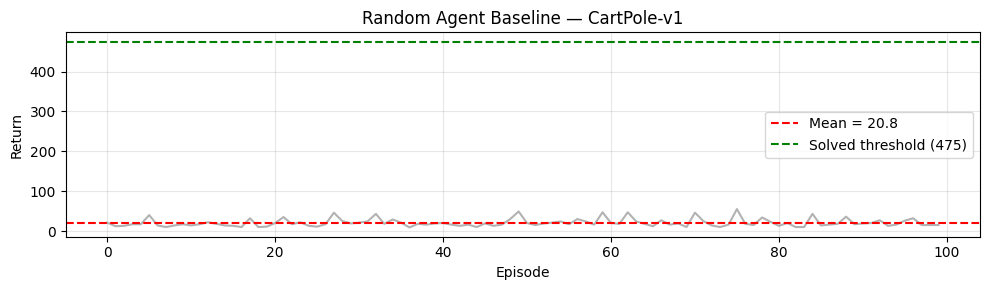

In [ ]:
# ------------------------------------------------------------------
# The full episode loop — with a RANDOM agent
# This is the baseline score we need to beat!
# ------------------------------------------------------------------

def run_random_agent(env_id, n_episodes=100, seed=42):
    env = gym.make(env_id)
    returns = []

    for ep in range(n_episodes):
        obs, _ = env.reset()   # no seed= after first reset
        total_reward = 0

        while True:
            action = env.action_space.sample()  # completely random
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            if terminated or truncated:
                break

        returns.append(total_reward)

    env.close()
    return returns


random_returns = run_random_agent("CartPole-v1", n_episodes=100)

print(f"Random agent over 100 episodes:")
print(f"  mean   = {np.mean(random_returns):.1f}")
print(f"  std    = {np.std(random_returns):.1f}")
print(f"  min    = {np.min(random_returns):.0f}")
print(f"  max    = {np.max(random_returns):.0f}")
print(f"")
print(f"CartPole is SOLVED when mean >= 475 over 100 episodes.")
print(f"Write down your random baseline — our DQN must beat this.")

plt.figure(figsize=(10, 3))
plt.plot(random_returns, alpha=0.6, color='gray')
plt.axhline(np.mean(random_returns), color='red', linestyle='--', label=f'Mean = {np.mean(random_returns):.1f}')
plt.axhline(475, color='green', linestyle='--', label='Solved threshold (475)')
plt.xlabel('Episode')
plt.ylabel('Return')
plt.title('Random Agent Baseline — CartPole-v1')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:

# Helper functions — needed later for FrozenLake (Discrete obs)


def obs_to_vector(obs, obs_space) -> np.ndarray:
    """Convert any obs to a flat float32 vector.
    - Box obs (CartPole, LunarLander) → just flatten
    - Discrete obs (FrozenLake)       → one-hot encode
    """
    if isinstance(obs_space, gym.spaces.Discrete):
        v = np.zeros(obs_space.n, dtype=np.float32)
        v[int(obs)] = 1.0
        return v
    if isinstance(obs_space, gym.spaces.Box):
        return np.asarray(obs, dtype=np.float32).reshape(-1)
    raise NotImplementedError(f"Unsupported obs space: {type(obs_space)}")


def infer_obs_dim(obs_space) -> int:
    """Return the flat input dimension for our Q-network."""
    if isinstance(obs_space, gym.spaces.Discrete):
        return int(obs_space.n)
    if isinstance(obs_space, gym.spaces.Box):
        return int(np.prod(obs_space.shape))
    raise NotImplementedError

print("Helper functions defined.")

Helper functions defined.


---
## Section 2 — Standard Benchmark Environments

Before building our agent, we need a mental map of **which environments exist, why they're used, and which algorithms they require**.

### The most important concept: Action Space Types

```
Discrete action space          Box (continuous) action space
──────────────────────         ──────────────────────────────
  [LEFT, RIGHT]                   [−2.0 ... +2.0]
       ↓                                 ↓
 Q-network outputs             Cannot enumerate all actions
 one value per action          → cannot do argmax
       ↓                                 ↓
  Works with DQN ✅             Needs PPO / SAC ✅
                                Broken with DQN ❌
```

> **Key rule:** First thing you do with any new environment — check `env.action_space`. If it's `Discrete` → DQN works. If it's `Box` → you need PPO or SAC.

In [ ]:
# ------------------------------------------------------------------
# The 3 space types you will encounter
# ------------------------------------------------------------------

# 1. Box — continuous, real-valued, bounded region
env = gym.make("CartPole-v1")
print("Box obs space (CartPole):")
print("  ", env.observation_space)       # Box(4,) — 4 continuous values
env.close()

env = gym.make("Pendulum-v1")
print("\nBox action space (Pendulum):")
print("  ", env.action_space)            # Box([-2.], [2.]) — continuous torque
print("   Agent outputs ANY float in [-2, 2] — infinite choices")
env.close()

print()

# 2. Discrete — finite set of integers 0 to n-1
env = gym.make("CartPole-v1")
print("Discrete action space (CartPole):")
print("  ", env.action_space)            # Discrete(2) — only 0 or 1
print("   Agent picks ONE integer from {0, 1, ..., n-1}")
env.close()

print()

# 3. Discrete obs — needs one-hot encoding before feeding to network
env = gym.make("FrozenLake-v1")
print("Discrete obs space (FrozenLake):")
print("  ", env.observation_space)       # Discrete(16) — grid position 0-15
print("   Must one-hot encode before passing to neural network")
env.close()

Box obs space (CartPole):
   Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)

Box action space (Pendulum):
   Box(-2.0, 2.0, (1,), float32)
   Agent outputs ANY float in [-2, 2] — infinite choices

Discrete action space (CartPole):
   Discrete(2)
   Agent picks ONE integer from {0, 1, ..., n-1}

Discrete obs space (FrozenLake):
   Discrete(16)
   Must one-hot encode before passing to neural network


In [ ]:
# ------------------------------------------------------------------
# Side-by-side comparison of all benchmark environments
# ------------------------------------------------------------------

envs_to_check = [
    "CartPole-v1",
    "LunarLander-v3",
    "FrozenLake-v1",
    "Pendulum-v1",
]

print(f"{'Environment':<22} {'Obs Space':<28} {'Act Space':<22} {'DQN?':<20} {'Difficulty'}")
print("-" * 105)

for env_id in envs_to_check:
    env  = gym.make(env_id)
    obs  = str(env.observation_space)[:26]
    act  = str(env.action_space)[:20]
    dqn  = "✅ Yes" if isinstance(env.action_space, gym.spaces.Discrete) else "❌ No → use PPO"
    diff = {"CartPole-v1": "Easy (unit test)",
            "LunarLander-v2": "Medium",
            "FrozenLake-v1": "Medium (sparse reward)",
            "Pendulum-v1": "Simple (but needs PPO)"}.get(env_id, "")
    print(f"{env_id:<22} {obs:<28} {act:<22} {dqn:<20} {diff}")
    env.close()

Environment            Obs Space                    Act Space              DQN?                 Difficulty
---------------------------------------------------------------------------------------------------------
CartPole-v1            Box([-4.8               -i   Discrete(2)            ✅ Yes                Easy (unit test)
LunarLander-v3         Box([ -2.5        -2.5       Discrete(4)            ✅ Yes                
FrozenLake-v1          Discrete(16)                 Discrete(4)            ✅ Yes                Medium (sparse reward)
Pendulum-v1            Box([-1. -1. -8.], [1. 1.    Box(-2.0, 2.0, (1,),   ❌ No → use PPO       Simple (but needs PPO)


In [ ]:
# ------------------------------------------------------------------
# CartPole-v1 — your debugging environment
# ------------------------------------------------------------------
env = gym.make("CartPole-v1")
print("CartPole-v1")
print("  Obs:        4 values — cart pos, cart vel, pole angle, pole angular vel")
print("  Actions:    2 — push LEFT or RIGHT")
print("  Reward:     +1 every timestep survived")
print("  DQN trains: ~50k steps (~2 min on CPU)")
print()
print("RULE: Always start here. If DQN can't solve CartPole, something is broken.")
print("      It's your unit test — fast enough to debug in minutes.")
env.close()

CartPole-v1
  Obs:        4 values — cart pos, cart vel, pole angle, pole angular vel
  Actions:    2 — push LEFT or RIGHT
  Reward:     +1 every timestep survived
  DQN trains: ~50k steps (~2 min on CPU)

RULE: Always start here. If DQN can't solve CartPole, something is broken.
      It's your unit test — fast enough to debug in minutes.


In [ ]:
# ------------------------------------------------------------------
# LunarLander-v2 — your main DQN target today
# ------------------------------------------------------------------
env = gym.make("LunarLander-v3")
print("LunarLander-v2")
print("  Obs:        8 values — x, y, vel_x, vel_y, angle, angular_vel, leg1, leg2")
print("  Actions:    4 — do nothing / fire left / fire main / fire right")
print("  Reward breakdown:")
print("    +100 to +140  successful landing on pad")
print("    -100          crash")
print("    +10           each leg touching ground")
print("    -0.3          per frame main engine fires (penalises fuel use)")
print("    -0.03         per frame side engine fires")
print("  Solved:     mean return >= 200 over 100 episodes")

print()
print("Common failure mode: agent learns to HOVER (avoids -100 crash)")
print("but never LANDS (misses +100-140 bonus). Classic local optimum.")
env.close()

LunarLander-v2
  Obs:        8 values — x, y, vel_x, vel_y, angle, angular_vel, leg1, leg2
  Actions:    4 — do nothing / fire left / fire main / fire right
  Reward breakdown:
    +100 to +140  successful landing on pad
    -100          crash
    +10           each leg touching ground
    -0.3          per frame main engine fires (penalises fuel use)
    -0.03         per frame side engine fires
  Solved:     mean return >= 200 over 100 episodes

Common failure mode: agent learns to HOVER (avoids -100 crash)
but never LANDS (misses +100-140 bonus). Classic local optimum.


In [ ]:
# ------------------------------------------------------------------
# FrozenLake-v1 — sparse reward challenge
# ------------------------------------------------------------------
env = gym.make("FrozenLake-v1", is_slippery=True)
print("FrozenLake-v1")
print("  Obs:     Single integer 0-15 (grid position) → needs one-hot encoding")
print("  Actions: 4 — up / down / left / right")
print("  Reward:  +1 ONLY on reaching the goal, 0 everywhere else")
print("  Map:")
print("    S  F  F  F      S=Start  F=Frozen(safe)")
print("    F  H  F  H      H=Hole   G=Goal")
print("    F  F  F  H")
print("    H  F  F  G")
print()
print("  is_slippery=True: action='right' has 33% chance of going up/down instead")
print()
print("The challenge: agent gets ZERO signal until it accidentally reaches the goal.")
print("Early training = falling in holes with reward=0 every episode.")
print("This is the SPARSE REWARD problem — a major challenge in RL.")
env.close()

FrozenLake-v1
  Obs:     Single integer 0-15 (grid position) → needs one-hot encoding
  Actions: 4 — up / down / left / right
  Reward:  +1 ONLY on reaching the goal, 0 everywhere else
  Map:
    S  F  F  F      S=Start  F=Frozen(safe)
    F  H  F  H      H=Hole   G=Goal
    F  F  F  H
    H  F  F  G

  is_slippery=True: action='right' has 33% chance of going up/down instead

The challenge: agent gets ZERO signal until it accidentally reaches the goal.
Early training = falling in holes with reward=0 every episode.
This is the SPARSE REWARD problem — a major challenge in RL.


In [ ]:
# ------------------------------------------------------------------
# MuJoCo environments — overview only, no install needed
# These require PPO/SAC because action space is Box (continuous)
# ------------------------------------------------------------------

print("MuJoCo Benchmark Environments (next session — PPO)")
print("-" * 55)
print(f"{'Env':<20} {'Obs':<8} {'Actions':<10} {'What it is'}")
print("-" * 55)
rows = [
    ("HalfCheetah-v4", "17",  "6 cont.",  "2-legged cheetah, maximise speed"),
    ("Hopper-v4",      "11",  "3 cont.",  "1-legged robot, don't fall"),
    ("Ant-v4",         "27",  "8 cont.",  "4-legged ant, navigate terrain"),
    ("Humanoid-v4",    "376", "17 cont.", "Bipedal human, hardest benchmark"),
]
for env_id, obs, act, desc in rows:
    print(f"{env_id:<20} {obs:<8} {act:<10} {desc}")

print()
print("All have Box action spaces → DQN CANNOT be used here.")
print("Random agent HalfCheetah: ~ -300 reward")
print("Trained PPO  HalfCheetah: ~+8000 reward")
print()
print("This gap is what good RL looks like on hard continuous control.")

MuJoCo Benchmark Environments (next session — PPO)
-------------------------------------------------------
Env                  Obs      Actions    What it is
-------------------------------------------------------
HalfCheetah-v4       17       6 cont.    2-legged cheetah, maximise speed
Hopper-v4            11       3 cont.    1-legged robot, don't fall
Ant-v4               27       8 cont.    4-legged ant, navigate terrain
Humanoid-v4          376      17 cont.   Bipedal human, hardest benchmark

All have Box action spaces → DQN CANNOT be used here.
Random agent HalfCheetah: ~ -300 reward
Trained PPO  HalfCheetah: ~+8000 reward

This gap is what good RL looks like on hard continuous control.


In [ ]:
# ------------------------------------------------------------------
# Decision framework: which env to use when?
# ------------------------------------------------------------------

print("""
HOW TO PICK THE RIGHT ENVIRONMENT
===================================

Is my algorithm working at all?
        ↓
    CartPole-v1           ← ALWAYS start here

Does it handle shaped rewards?
        ↓
    LunarLander-v2        ← medium difficulty, still DQN

Does it handle sparse rewards?
        ↓
    FrozenLake-v1         ← specific sparse reward challenge

Does it handle continuous actions?
        ↓
    Pendulum-v1           ← simplest continuous env (PPO)
    HalfCheetah-v4        ← standard research benchmark (PPO)

GOLDEN RULE: Never skip CartPole. A bug CartPole catches in 2 minutes
             would cost you 2 hours on HalfCheetah.
""")


HOW TO PICK THE RIGHT ENVIRONMENT

Is my algorithm working at all?
        ↓
    CartPole-v1           ← ALWAYS start here

Does it handle shaped rewards?
        ↓
    LunarLander-v2        ← medium difficulty, still DQN

Does it handle sparse rewards?
        ↓
    FrozenLake-v1         ← specific sparse reward challenge

Does it handle continuous actions?
        ↓
    Pendulum-v1           ← simplest continuous env (PPO)
    HalfCheetah-v4        ← standard research benchmark (PPO)

GOLDEN RULE: Never skip CartPole. A bug CartPole catches in 2 minutes
             would cost you 2 hours on HalfCheetah.



---
##  Section 3 — Replay Buffer

The replay buffer stores past transitions `(s, a, s', r, done)` and allows us to sample **random mini-batches** for training.

**Why do we need it?**
- Breaks temporal correlations between consecutive samples
- Re-uses past experience (data efficiency)
- Without it, the Q-network will diverge (we prove this in Section 9)

```
Store:  (s, a, s', r, done)  ──►  circular buffer (maxlen = capacity)
Sample: random batch of size B  ──►  used for one gradient update
```

In [ ]:
class ReplayBuffer:
    """
    Circular replay buffer storing (state, action, next_state, reward, done).
    Uses deque for O(1) append + automatic eviction of oldest transitions.
    """
    def __init__(self, capacity: int, device: str = "cpu"):
        self.capacity = capacity
        self.device   = device

        # One deque per field — maxlen handles circular eviction automatically
        self.states      = deque(maxlen=capacity)
        self.actions     = deque(maxlen=capacity)
        self.next_states = deque(maxlen=capacity)
        self.rewards     = deque(maxlen=capacity)
        self.dones       = deque(maxlen=capacity)

    def store(self, state, action, next_state, reward, done):
        """Add one transition to the buffer."""
        self.states.append(state)
        self.actions.append(action)
        self.next_states.append(next_state)
        self.rewards.append(reward)
        self.dones.append(done)

    def sample(self, batch_size: int):
        """Sample a random batch — this is what breaks temporal correlations."""
        indices = np.random.choice(len(self), size=batch_size, replace=False)
        d = self.device

        states = torch.stack([
            torch.as_tensor(self.states[i], dtype=torch.float32, device=d)
            for i in indices
        ])
        actions = torch.as_tensor(
            [self.actions[i] for i in indices], dtype=torch.long, device=d
        )
        next_states = torch.stack([
            torch.as_tensor(self.next_states[i], dtype=torch.float32, device=d)
            for i in indices
        ])
        rewards = torch.as_tensor(
            [self.rewards[i] for i in indices], dtype=torch.float32, device=d
        )
        dones = torch.as_tensor(
            [self.dones[i] for i in indices], dtype=torch.float32, device=d
        )
        return states, actions, next_states, rewards, dones

    def __len__(self):
        return len(self.states)


# Sanity check
buf = ReplayBuffer(capacity=1000)
buf.store(np.zeros(4), 0, np.ones(4), 1.0, False)
buf.store(np.ones(4),  1, np.zeros(4), 0.0, True)
print(f"Buffer size: {len(buf)}")
s, a, ns, r, d = buf.sample(2)
print(f"Sampled batch — states: {s.shape}, actions: {a}, rewards: {r}")

Buffer size: 2
Sampled batch — states: torch.Size([2, 4]), actions: tensor([1, 0]), rewards: tensor([0., 1.])


---
##  Section 4 — Q-Network

The Q-network takes a **state** as input and outputs **Q-values for every action**.

```
Input:  state  (state_dim,)
           │
     Linear → ReLU
     Linear → ReLU
           │
Output: Q(s,a₀), Q(s,a₁), ..., Q(s,aₙ)    shape: (action_dim,)
```

We maintain **two identical networks**:
- `q_net` — updated every step (online network)
- `target_net` — updated every N steps (provides stable TD targets)

In [ ]:
class QNetwork(nn.Module):
    """
    MLP: state_dim → [hidden layers] → action_dim
    No activation on output — Q-values are unbounded real numbers.
    """
    def __init__(self, state_dim: int, action_dim: int, hidden_sizes: tuple = (256, 256)):
        super().__init__()

        layers = []
        in_dim = state_dim
        for h in hidden_sizes:
            layers += [nn.Linear(in_dim, h), nn.ReLU()]
            in_dim = h
        layers.append(nn.Linear(in_dim, action_dim))  # NO activation here!

        self.net = nn.Sequential(*layers)

        # Orthogonal init — stabilises early training
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)   # (B, action_dim)


# Sanity check
net   = QNetwork(state_dim=4, action_dim=2)
dummy = torch.zeros(8, 4)     # batch of 8 states
out   = net(dummy)
print(f"Input shape:  {dummy.shape}  →  Output shape: {out.shape}")
print(f"Output (Q-values for each action):\n{out[:3]}")
print("Note: values can be negative — Q-values have no activation constraint")

Input shape:  torch.Size([8, 4])  →  Output shape: torch.Size([8, 2])
Output (Q-values for each action):
tensor([[0., 0.],
        [0., 0.],
        [0., 0.]], grad_fn=<SliceBackward0>)
Note: values can be negative — Q-values have no activation constraint


---
##  Section 5 — DQN Agent

The agent combines everything:

### ε-greedy policy
- With probability ε → random action (exploration)
- With probability 1-ε → `argmax Q(s,a)` (exploitation)
- ε decays linearly: `ε_start → ε_end` over `decay_steps`

### Bellman update
```
target  =  r  +  γ · (1 − done) · max_a' Q_target(s', a')
loss    =  HuberLoss( Q(s, a),  target )
```

> **Why Huber loss instead of MSE?**  
> MSE squares large errors — one outlier reward can blow up your gradients.  
> Huber behaves like MSE for small errors, linear for large ones. More stable.

Intuition:
Trust small errors AND Don't overreact to big mistakes

In [ ]:
class DQNAgent:
    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        device: str = "cpu",
        gamma: float = 0.99,
        lr: float = 1e-3,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay_steps: int = 50_000,
        hidden_sizes: tuple = (256, 256),
        clip_grad_norm: Optional[float] = 10.0,
    ):
        self.device     = device
        self.gamma      = gamma
        self.action_dim = action_dim

        self.epsilon_start       = epsilon_start
        self.epsilon_end         = epsilon_end
        self.epsilon_decay_steps = epsilon_decay_steps
        self.total_steps         = 0
        self.clip_grad_norm      = clip_grad_norm

        # Online network — updated every training step
        self.q_net = QNetwork(state_dim, action_dim, hidden_sizes).to(device)

        # Target network — hard-copied every N steps, never trained directly
        self.target_net = QNetwork(state_dim, action_dim, hidden_sizes).to(device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.q_net.parameters(), lr=lr)

    # ------------------------------------------------------------------
    # ε-greedy
    # ------------------------------------------------------------------

    def _epsilon(self) -> float:
        """Linear decay from epsilon_start to epsilon_end over decay_steps."""
        frac = min(1.0, self.total_steps / max(1, self.epsilon_decay_steps))
        return self.epsilon_end + (self.epsilon_start - self.epsilon_end) * (1.0 - frac)

    def select_action(self, state: np.ndarray) -> int:
        self.total_steps += 1
        if random.random() < self._epsilon():
            return random.randrange(self.action_dim)       # explore
        state_t = torch.as_tensor(state, dtype=torch.float32, device=self.device).unsqueeze(0)
        with torch.no_grad():
            q_values = self.q_net(state_t)                 # (1, action_dim)
        return int(q_values.argmax(dim=1).item())          # exploit

    # ------------------------------------------------------------------
    # Training update — the core DQN loss
    # ------------------------------------------------------------------

    def update(self, buffer: ReplayBuffer, batch_size: int):
        if len(buffer) < batch_size:
            return None

        states, actions, next_states, rewards, dones = buffer.sample(batch_size)

        states      = states.to(self.device)
        actions     = actions.to(self.device).view(-1, 1)   # (B,1) for gather
        next_states = next_states.to(self.device)
        rewards     = rewards.to(self.device).view(-1)
        dones       = dones.to(self.device).view(-1)

        # Q(s, a) — only for the action that was actually taken
        # .gather picks the Q-value at the index specified by actions
        q_all    = self.q_net(states)                       # (B, action_dim)
        q_values = q_all.gather(1, actions).squeeze(1)      # (B,)

        # TD target — computed with target_net, no gradient
        with torch.no_grad():
            next_q_max = self.target_net(next_states).max(dim=1).values  # (B,)
            targets = rewards + self.gamma * (1.0 - dones) * next_q_max

        # Huber loss — robust to reward outliers
        loss = F.smooth_l1_loss(q_values, targets)

        self.optimizer.zero_grad()
        loss.backward()
        if self.clip_grad_norm is not None:
            nn.utils.clip_grad_norm_(self.q_net.parameters(), self.clip_grad_norm)
        self.optimizer.step()

        return {"loss": loss.item(), "epsilon": self._epsilon()}

    # ------------------------------------------------------------------
    # Target network sync
    # ------------------------------------------------------------------

    def sync_target(self):
        """Hard update: copy online network weights → target network."""
        self.target_net.load_state_dict(self.q_net.state_dict())

    def save(self, path: str):
        torch.save(self.q_net.state_dict(), path)


print("DQNAgent defined.")

DQNAgent defined.


---
## Section 6 — Training Loop

The training loop ties everything together:

```
for each step:
    1.  obs → agent.select_action()      # ε-greedy
    2.  env.step(action)                 # interact with env
    3.  buffer.store(transition)         # remember what happened
    4.  agent.update(buffer)             # learn (after learning_starts)
    5.  agent.sync_target()              # every target_update_freq steps
```

### Key hyperparameters — try changing these!

In [ ]:
# ============================================================
#   HYPERPARAMETERS — edit these and observe the effect
# ============================================================

ENV_ID               = "CartPole-v1"   # try: LunarLander-v2, FrozenLake-v1
SEED                 = 0

TOTAL_STEPS          = 200_000
REPLAY_CAPACITY      = 50_000
BATCH_SIZE           = 64

GAMMA                = 0.99
LR                   = 1e-4

EPSILON_START        = 1.0
EPSILON_END          = 0.05
EPSILON_DECAY_STEPS  = 20_000

LEARNING_STARTS      = 1_000     # fill buffer before training starts
TRAIN_FREQ           = 4         # update every N steps
TARGET_UPDATE_FREQ   = 1000     # hard sync every N steps

HIDDEN_SIZES         = (256, 256)
CLIP_GRAD_NORM       = 10.0

In [ ]:
def smooth(values, window=20):
    if len(values) < window:
        return values
    return np.convolve(values, np.ones(window)/window, mode='valid')


def train_dqn(
    env_id, seed, total_steps, replay_capacity, batch_size,
    gamma, lr, epsilon_start, epsilon_end, epsilon_decay_steps,
    learning_starts, train_freq, target_update_freq,
    hidden_sizes, clip_grad_norm, device,
):
    set_seed(seed)

    env        = gym.make(env_id)
    obs_dim    = infer_obs_dim(env.observation_space)
    action_dim = int(env.action_space.n)

    buffer = ReplayBuffer(capacity=replay_capacity, device=device)
    agent  = DQNAgent(
        state_dim=obs_dim, action_dim=action_dim, device=device,
        gamma=gamma, lr=lr,
        epsilon_start=epsilon_start, epsilon_end=epsilon_end,
        epsilon_decay_steps=epsilon_decay_steps,
        hidden_sizes=hidden_sizes, clip_grad_norm=clip_grad_norm,
    )

    episode_returns, episode_losses = [], []

    obs, _        = env.reset(seed=seed)  # seed only on first reset
    obs_vec       = obs_to_vector(obs, env.observation_space)
    ep_return     = 0.0
    ep_loss_sum   = 0.0
    ep_loss_count = 0
    ep_idx        = 0
    t0            = time.time()

    for step in range(1, total_steps + 1):

        # 1. Select action (ε-greedy)
        action = agent.select_action(obs_vec)

        # 2. Step environment
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done         = terminated or truncated
        next_obs_vec = obs_to_vector(next_obs, env.observation_space)

        # 3. Store transition
        buffer.store(obs_vec, action, next_obs_vec, float(reward), float(done))
        ep_return += reward

        # 4. Train (only after buffer has enough samples)
        if step >= learning_starts and step % train_freq == 0:
            stats = agent.update(buffer, batch_size)
            if stats:
                ep_loss_sum   += stats["loss"]
                ep_loss_count += 1

        # 5. Sync target network
        if step % target_update_freq == 0:
            agent.sync_target()

        # ---- Episode bookkeeping ----
        if done:
            ep_idx  += 1
            avg_loss = ep_loss_sum / max(1, ep_loss_count)
            episode_returns.append(ep_return)
            episode_losses.append(avg_loss)

            if ep_idx % 20 == 0:
                recent = np.mean(episode_returns[-20:])
                print(
                    f"Ep {ep_idx:4d} | step {step:7d} | "
                    f"return {ep_return:7.1f} | avg20 {recent:7.1f} | "
                    f"ε={agent._epsilon():.3f} | loss={avg_loss:.5f} | "
                    f"{time.time()-t0:.0f}s"
                )
              # At the end of train_dqn(), before return, add:
            if ep_idx % 100 == 0 and ep_idx > 0:
                from IPython.display import clear_output
                clear_output(wait=True)

                fig, axes = plt.subplots(1, 2, figsize=(14, 4))

                ax = axes[0]
                ax.plot(episode_returns, alpha=0.3, color='steelblue')
                ax.plot(smooth(episode_returns), color='steelblue', linewidth=2)
                ax.axhline(475, color='green', linestyle='--', label='Solved (475)')
                ax.set_title(f'Return — Episode {ep_idx}')
                ax.set_xlabel('Episode')
                ax.set_ylabel('Return')
                ax.legend()
                ax.grid(alpha=0.3)

                ax = axes[1]
                ax.plot(episode_losses, alpha=0.3, color='darkorange')
                ax.plot(smooth(episode_losses), color='darkorange', linewidth=2)
                ax.set_title('Loss')
                ax.set_xlabel('Episode')
                ax.grid(alpha=0.3)

                plt.tight_layout()
                plt.show()
                print(f"Ep {ep_idx} | avg20={np.mean(episode_returns[-20:]):.1f} | ε={agent._epsilon():.3f}")

            # Reset — no seed here so each episode is different!
            obs, _        = env.reset()
            obs_vec       = obs_to_vector(obs, env.observation_space)
            ep_return     = 0.0
            ep_loss_sum   = 0.0
            ep_loss_count = 0
        else:
            obs_vec = next_obs_vec

    env.close()
    return agent, episode_returns, episode_losses

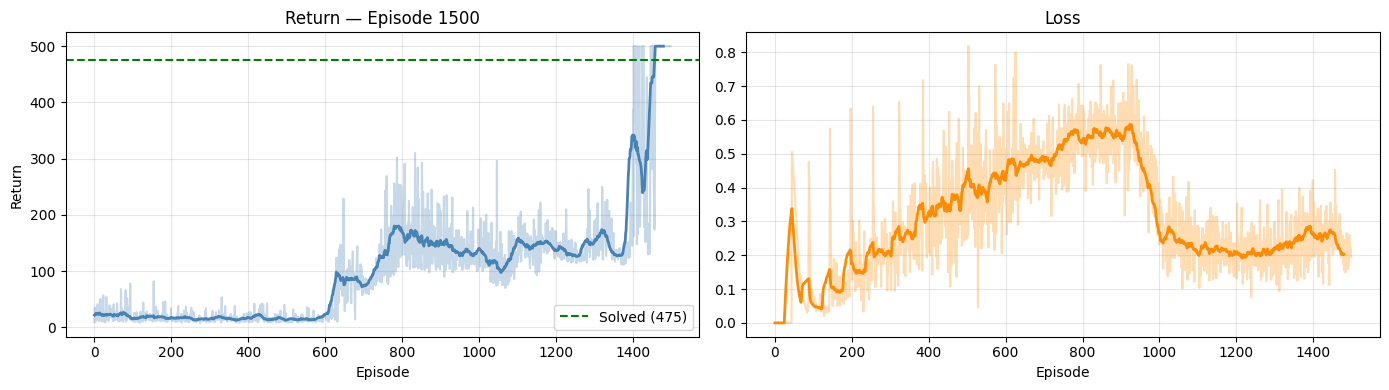

Ep 1500 | avg20=500.0 | ε=0.050
Ep 1520 | step  163602 | return   500.0 | avg20   500.0 | ε=0.050 | loss=0.21284 | 339s
Ep 1540 | step  173602 | return   500.0 | avg20   500.0 | ε=0.050 | loss=0.14227 | 359s
Ep 1560 | step  183602 | return   500.0 | avg20   500.0 | ε=0.050 | loss=0.19534 | 380s
Ep 1580 | step  193602 | return   500.0 | avg20   500.0 | ε=0.050 | loss=0.11609 | 401s


In [ ]:
# ▶ Run training!
agent, ep_returns, ep_losses = train_dqn(
    env_id=ENV_ID, seed=SEED, total_steps=TOTAL_STEPS,
    replay_capacity=REPLAY_CAPACITY, batch_size=BATCH_SIZE,
    gamma=GAMMA, lr=LR,
    epsilon_start=EPSILON_START, epsilon_end=EPSILON_END,
    epsilon_decay_steps=EPSILON_DECAY_STEPS,
    learning_starts=LEARNING_STARTS, train_freq=TRAIN_FREQ,
    target_update_freq=TARGET_UPDATE_FREQ,
    hidden_sizes=HIDDEN_SIZES, clip_grad_norm=CLIP_GRAD_NORM,
    device=device,
)

---
##  Section 7 — Visualize Results

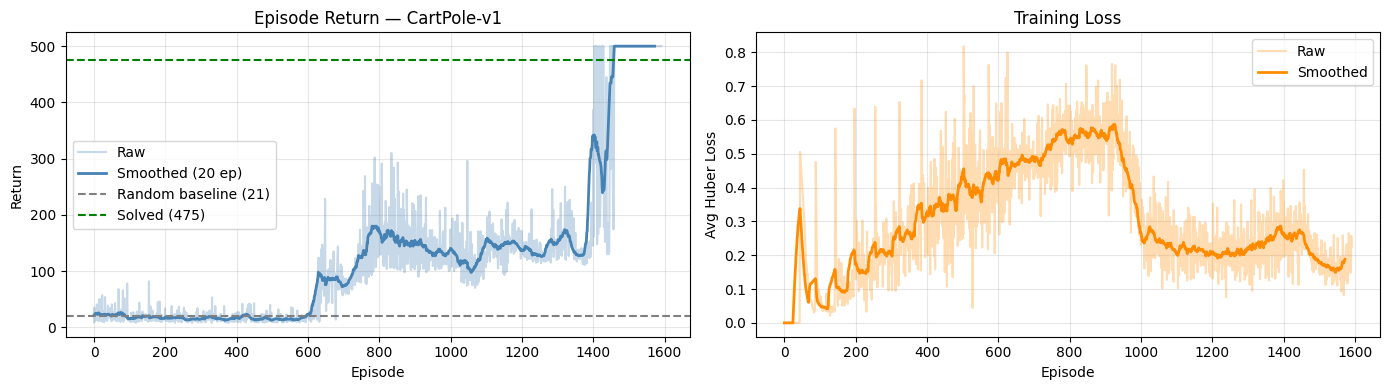

Final 20-episode avg return: 500.0  (random baseline: 20.8)


In [ ]:



fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Episode returns
ax = axes[0]
ax.plot(ep_returns, alpha=0.3, color='steelblue', label='Raw')
ax.plot(smooth(ep_returns), color='steelblue', linewidth=2, label='Smoothed (20 ep)')
ax.axhline(np.mean(random_returns), color='gray',  linestyle='--', label=f'Random baseline ({np.mean(random_returns):.0f})')
ax.axhline(475,                     color='green', linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode')
ax.set_ylabel('Return')
ax.set_title(f'Episode Return — {ENV_ID}')
ax.legend()
ax.grid(alpha=0.3)

# Training loss
ax = axes[1]
ax.plot(ep_losses, alpha=0.3, color='darkorange', label='Raw')
ax.plot(smooth(ep_losses), color='darkorange', linewidth=2, label='Smoothed')
ax.set_xlabel('Episode')
ax.set_ylabel('Avg Huber Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Final 20-episode avg return: {np.mean(ep_returns[-20:]):.1f}  (random baseline: {np.mean(random_returns):.1f})")

---
## Section 8 — Evaluation (Greedy Policy)

In [ ]:
@torch.no_grad()
def evaluate(agent, env_id, episodes=10, device="cpu"):
    """Run greedy policy (ε=0) for N episodes."""
    env = gym.make(env_id)
    agent.q_net.eval()
    returns = []

    for ep in range(episodes):
        obs, _  = env.reset(seed=ep)
        obs_vec = obs_to_vector(obs, env.observation_space)
        ep_ret, done = 0.0, False
        while not done:
            state_t = torch.as_tensor(obs_vec, dtype=torch.float32, device=device).unsqueeze(0)
            action  = int(agent.q_net(state_t).argmax(dim=1).item())
            obs, reward, terminated, truncated, _ = env.step(action)
            obs_vec  = obs_to_vector(obs, env.observation_space)
            ep_ret  += reward
            done     = terminated or truncated
        returns.append(ep_ret)

    env.close()
    print(f"Eval ({episodes} eps) → mean={np.mean(returns):.1f}  std={np.std(returns):.1f}  "
          f"min={np.min(returns):.0f}  max={np.max(returns):.0f}")
    return returns


eval_returns = evaluate(agent, ENV_ID, episodes=10, device=device)

Eval (10 eps) → mean=500.0  std=0.0  min=500  max=500


In [ ]:
!pip install imageio[ffmpeg] -q

In [ ]:
import imageio

def evaluate_and_record(agent, env_id, device="cpu", filepath="cartpole.gif"):
    """Run one greedy episode and save it as a GIF."""

    env = gym.make(env_id, render_mode="rgb_array")
    agent.q_net.eval()

    obs, _  = env.reset(seed=42)
    obs_vec = obs_to_vector(obs, env.observation_space)
    frames  = []
    ep_ret  = 0.0
    done    = False

    while not done:
        # Capture frame
        frames.append(env.render())

        # Greedy action
        state_t = torch.as_tensor(obs_vec, dtype=torch.float32, device=device).unsqueeze(0)
        with torch.no_grad():
            action = int(agent.q_net(state_t).argmax(dim=1).item())

        obs, reward, terminated, truncated, _ = env.step(action)
        obs_vec  = obs_to_vector(obs, env.observation_space)
        ep_ret  += reward
        done     = terminated or truncated

    env.close()

    # Save as GIF
    imageio.mimsave(filepath, frames, fps=30)
    print(f"Episode return: {ep_ret:.0f} | Saved to {filepath}")
    return filepath

Episode return: 500 | Saved to cartpole.gif


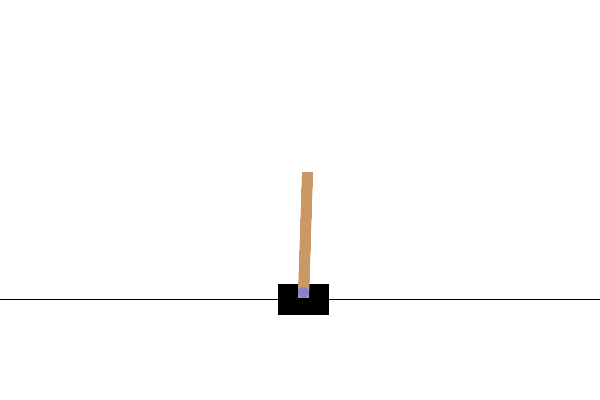

In [ ]:
# Display the GIF inline in Colab
from IPython.display import Image

gif_path = evaluate_and_record(agent, ENV_ID, device=device)
Image(gif_path)

---
##  Section 9 — Experiments & Discussion

Run each experiment, observe what happens, then reveal the solution cell to check your reasoning.

### Experiment 1 — Ablate the Target Network

In `DQNAgent.update()`, find this line:
```python
next_q_max = self.target_net(next_states).max(dim=1).values
```
Change `self.target_net` → `self.q_net`, then retrain.

**Observe:** What happens to the loss curve? Does the agent learn?

<details>
<summary> Click to reveal answer — Experiment 1</summary>

**What you should see:** The loss curve oscillates wildly and likely diverges. The agent may briefly improve then catastrophically forget.

**Why:** Without a frozen target network, every weight update changes *both* sides of the loss:
```
loss = ( Q(s,a)  −  [r + γ · max Q(s',a')] )²
          ↑                    ↑
    this changes          this ALSO changes
```
The network is chasing a moving target — every step you get closer, the target jumps away. This is called the **deadly triad** and is one of the classic DQN instabilities.

The target network solves this by freezing the right-hand side for N steps, giving the optimizer a stable signal to converge toward.
</details>

### Experiment 2 — Ablate the Replay Buffer

Change the hyperparameter:
```python
REPLAY_CAPACITY = BATCH_SIZE   # only keep the last 64 transitions
```
Retrain and compare to the full buffer run.

**Observe:** Is training more or less stable? Does it converge?

<details>
<summary> Click to reveal answer — Experiment 2</summary>

**What you should see:** Very noisy training, possible early learning followed by forgetting, much worse final performance.

**Two things break simultaneously:**

**Problem 1 — Correlated samples:**  
Consecutive CartPole frames are nearly identical — the cart moved 1mm. If your entire batch is 64 consecutive steps, you're showing the network the same situation 64 times. It overfits to that one situation and forgets everything else.

**Problem 2 — Catastrophic forgetting:**  
Without old experiences, the network only learns from what just happened. If the agent is currently stuck in a bad region, it only sees bad transitions and overwrites everything it previously learned.

**Key insight:** The replay buffer is not an optimization trick — it's a fundamental stability requirement. Without it you don't have DQN, you have online gradient descent on a non-stationary distribution.
</details>

### Experiment 3 — Tune ε-decay

Try both:
```python
EPSILON_DECAY_STEPS = 5_000    # fast decay — stops exploring early
EPSILON_DECAY_STEPS = 500_000  # slow decay — stays exploratory longer
```
**Observe:** Which works better on CartPole? What do you predict would happen on LunarLander?

<details>
<summary> Click to reveal answer — Experiment 3</summary>

**Fast decay (5k steps) on CartPole:** Can still work — state space is small, the agent stumbles onto good behavior early and exploits it fine.

**Slow decay (500k steps) on CartPole:** Overkill — wastes many steps taking random actions when the agent already knows what to do.

**Fast decay on LunarLander:** Fails badly. The agent gets stuck hovering (a local optimum) because it stopped exploring before finding the reward signal for actually landing.

**Rule of thumb:**
| Environment | Recommended decay |
|---|---|
| CartPole (simple) | ~10-20% of total steps |
| LunarLander (complex) | ~50% of total steps |
| FrozenLake (sparse) | Very slow, or use curiosity exploration |

ε-decay is a schedule for shifting from *figuring out the world* to *exploiting what you know*. Decay too fast and you never understand the world. Too slow and you waste time being random.
</details>

### Experiment 4 — Switch to LunarLander

```python
ENV_ID      = "LunarLander-v2"
TOTAL_STEPS = 500_000
```
Use the same hyperparameters as CartPole. Does it work?

**Observe:** How long before you see any learning signal? Does it reach the solved threshold (200)?

<details>
<summary> Click to reveal answer — Experiment 4</summary>

**What you should see:** Returns stay flat or negative for a long time (~100k steps) before any learning appears. This is normal — the reward for landing is rare early on, the agent has to stumble into it first.

**What breaks with CartPole hyperparams:**
| Hyperparameter | CartPole | LunarLander problem |
|---|---|---|
| `TOTAL_STEPS=100k` | Enough | Way too few |
| `EPSILON_DECAY=50k` | Fine | Decays before agent understands the env |
| `HIDDEN=(128,128)` | Fine | Borderline — (256,256) more reliable |

**Recommended LunarLander settings:**
```python
TOTAL_STEPS         = 500_000
EPSILON_DECAY_STEPS = 200_000
HIDDEN_SIZES        = (256, 256)
LEARNING_STARTS     = 5_000
```

**The deeper lesson:** There are no universal hyperparameters in RL. Every environment has different reward scale, state complexity, and episode length. Hyperparameter tuning is not a formality — it's often the difference between an agent that learns and one that does nothing for 1 million steps.
</details>

---
## Bonus — Using Stable-Baselines3

In practice, researchers use well-tested implementations. Let's compare your scratch DQN to SB3:

In [ ]:
!pip install stable-baselines3 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 6.5 MB/s eta 0:00:00


In [ ]:
from stable_baselines3 import DQN as SB3_DQN
from stable_baselines3.common.evaluation import evaluate_policy

sb3_env   = gym.make(ENV_ID)
sb3_model = SB3_DQN(
    "MlpPolicy", sb3_env,
    learning_rate=LR,
    gamma=GAMMA,
    batch_size=BATCH_SIZE,
    verbose=1,
)
sb3_model.learn(total_timesteps=TOTAL_STEPS)

mean_reward, std_reward = evaluate_policy(sb3_model, sb3_env, n_eval_episodes=10)
print(f"\nSB3 DQN  → mean={mean_reward:.1f}  std={std_reward:.1f}")
print(f"Our DQN  → mean={np.mean(eval_returns):.1f}")
sb3_env.close()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 14.8     |
|    ep_rew_mean      | 14.8     |
|    exploration_rate | 0.997    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 2493     |
|    time_elapsed     | 0        |
|    total_timesteps  | 59       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 15.9     |
|    ep_rew_mean      | 15.9     |
|    exploration_rate | 0.994    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1122     |
|    time_elapsed     | 0        |
|    total_timesteps  | 127      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.538    |
|    n_updates        | 6        |
-------------------------------

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0384   |
|    n_updates        | 5254     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18.3     |
|    ep_rew_mean      | 18.3     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1216     |
|    fps              | 850      |
|    time_elapsed     | 24       |
|    total_timesteps  | 21229    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0358   |
|    n_updates        | 5282     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 18.8     |
|    ep_rew_mean      | 18.8     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 1220     |
|   

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(



SB3 DQN  → mean=108.8  std=6.0
Our DQN  → mean=500.0


---
## Summary

| Component | Key idea | What breaks without it |
|---|---|---|
| **Replay Buffer** | Random sampling breaks temporal correlation | Correlated gradients, catastrophic forgetting |
| **Q-Network** | MLP: state → Q-value per action | No output activation — Q-values are unbounded |
| **Target Network** | Frozen copy gives stable TD targets | Loss oscillates, deadly triad |
| **ε-greedy** | Decay from 1.0 → 0.05 over training | Too fast = local optima; too slow = wastes steps |
| **Huber Loss** | Robust to large reward outliers | MSE explodes on high-reward envs |
| **Grad Clipping** | Prevents exploding gradients | Unstable on envs with large reward values |

### Space types recap
| Space | Meaning | Algorithm |
|---|---|---|
| `Discrete(n)` | Finite set of n actions | DQN ✅ |
| `Box(shape)` | Continuous real-valued | PPO / SAC ✅, DQN ❌ |

**Next session → PPO** — on-policy, continuous action spaces, MuJoCo locomotion